# Day 6: Employee Attrition Pattern Analyser

**Industry:** HR / Recruitment  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · seaborn · matplotlib · correlation analysis · groupby · feature encoding

**Data:** IBM HR Analytics Employee Attrition Dataset — 1,470 employees, 35 features

---

## Who uses this
An **HR director** deciding where to focus retention programmes. Instead of waiting for exit interviews, this notebook surfaces the patterns that predict attrition months in advance — by department, tenure band, salary, overtime, and satisfaction scores.

## Problem
Employee turnover costs 1.5–2x annual salary per employee to replace. HR teams typically act on attrition after it happens — this analysis shows the warning signs visible in the data before someone resigns. Identifying which departments, roles, and satisfaction factors drive attrition allows targeted interventions rather than blanket retention spend.

## What we build
1. Load and inspect the IBM HR dataset
2. Clean and encode for analysis
3. Attrition rate by department, job role, overtime, marital status
4. Salary and tenure analysis — do underpaid or short-tenure employees leave more?
5. Satisfaction score analysis — which satisfaction dimension matters most?
6. Correlation heatmap — full feature relationships
7. Cost-of-turnover estimate per department
8. Export intervention priority list

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load and Inspect the Data

In [2]:
df = pd.read_csv('hr_attrition.csv')

print(f'Shape: {df.shape}')
print(f'Attrition breakdown:')
print(df['Attrition'].value_counts())
print(f'\nAttrition rate: {df["Attrition"].eq("Yes").mean()*100:.1f}%')
print(f'\nDepartments: {df["Department"].unique().tolist()}')
print(f'Job roles: {df["JobRole"].nunique()} unique roles')
print(f'\nAge range: {df["Age"].min()} to {df["Age"].max()}')
print(f'Salary range: ${df["MonthlyIncome"].min():,} to ${df["MonthlyIncome"].max():,}/month')
df.head(3)

Shape: (1470, 35)
Attrition breakdown:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%

Departments: ['Sales', 'Research & Development', 'Human Resources']
Job roles: 9 unique roles

Age range: 18 to 60
Salary range: $1,009 to $19,999/month


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


## Step 3 — Clean and Encode

We create a numeric attrition flag (1=Yes, 0=No) for calculations, encode key categorical columns, and create useful derived features like tenure bands and salary bands.

In [3]:
# Numeric attrition flag
df['AttritionFlag'] = (df['Attrition'] == 'Yes').astype(int)

# Drop columns with no variance — not useful for analysis
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'], errors='ignore')

# Tenure bands
df['TenureBand'] = pd.cut(
    df['YearsAtCompany'],
    bins=[0, 2, 5, 10, 20, 100],
    labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', '20+ yrs'],
    include_lowest=True
)

# Salary bands
df['SalaryBand'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0, 3000, 6000, 10000, 25000],
    labels=['Low (<$3k)', 'Mid ($3-6k)', 'Upper ($6-10k)', 'High (>$10k)'],
    include_lowest=True
)

# Age bands
df['AgeBand'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 60],
    labels=['18-25', '26-35', '36-45', '46-60'],
    include_lowest=True
)

print(f'Clean shape: {df.shape}')
print(f'\nTenure band distribution:')
print(df['TenureBand'].value_counts().sort_index().to_string())
print(f'\nSalary band distribution:')
print(df['SalaryBand'].value_counts().sort_index().to_string())

Clean shape: (1470, 36)

Tenure band distribution:
TenureBand
0-2 yrs      342
3-5 yrs      434
6-10 yrs     448
11-20 yrs    180
20+ yrs       66

Salary band distribution:
SalaryBand
Low (<$3k)        395
Mid ($3-6k)       519
Upper ($6-10k)    275
High (>$10k)      281


## Step 4 — Attrition Rate Analysis

We calculate attrition rate across every key dimension. **Attrition rate = employees who left / total employees in that group.**

This tells HR exactly which groups are at highest risk.

In [4]:
def attrition_rate(df, col):
    return (
        df.groupby(col)['AttritionFlag']
        .agg(['mean', 'sum', 'count'])
        .rename(columns={'mean': 'attrition_rate', 'sum': 'left', 'count': 'total'})
        .assign(attrition_rate=lambda x: (x['attrition_rate'] * 100).round(1))
        .sort_values('attrition_rate', ascending=False)
    )

by_dept      = attrition_rate(df, 'Department')
by_role      = attrition_rate(df, 'JobRole')
by_overtime  = attrition_rate(df, 'OverTime')
by_tenure    = attrition_rate(df, 'TenureBand')
by_salary    = attrition_rate(df, 'SalaryBand')
by_travel    = attrition_rate(df, 'BusinessTravel')
by_marital   = attrition_rate(df, 'MaritalStatus')
by_age       = attrition_rate(df, 'AgeBand')

print('=== Attrition rate by department ===')
print(by_dept.to_string())
print('\n=== Attrition rate by job role ===')
print(by_role.to_string())
print('\n=== Attrition rate by overtime ===')
print(by_overtime.to_string())
print('\n=== Attrition rate by tenure band ===')
print(by_tenure.to_string())
print('\n=== Attrition rate by salary band ===')
print(by_salary.to_string())

=== Attrition rate by department ===
                        attrition_rate  left  total
Department                                         
Sales                             20.6    92    446
Human Resources                   19.0    12     63
Research & Development            13.8   133    961

=== Attrition rate by job role ===
                           attrition_rate  left  total
JobRole                                               
Sales Representative                 39.8    33     83
Laboratory Technician                23.9    62    259
Human Resources                      23.1    12     52
Sales Executive                      17.5    57    326
Research Scientist                   16.1    47    292
Healthcare Representative             6.9     9    131
Manufacturing Director                6.9    10    145
Manager                               4.9     5    102
Research Director                     2.5     2     80

=== Attrition rate by overtime ===
          attrition_rate  

## Step 5 — Satisfaction Score Analysis

The IBM dataset has 4 satisfaction dimensions scored 1-4:
- **JobSatisfaction** — how satisfied with their role
- **EnvironmentSatisfaction** — physical workplace satisfaction
- **WorkLifeBalance** — perceived work-life balance
- **RelationshipSatisfaction** — relationship with manager/colleagues

We compare average scores for employees who left vs stayed.

In [5]:
satisfaction_cols = [
    'JobSatisfaction', 'EnvironmentSatisfaction',
    'WorkLifeBalance', 'RelationshipSatisfaction', 'JobInvolvement'
]

sat_comparison = df.groupby('Attrition')[satisfaction_cols].mean().round(2).T
sat_comparison.columns = ['Stayed', 'Left']
sat_comparison['Difference'] = (sat_comparison['Left'] - sat_comparison['Stayed']).round(2)
sat_comparison['Impact'] = sat_comparison['Difference'].apply(
    lambda x: 'Lower when leaving' if x < 0 else 'Higher when leaving'
)

print('=== Satisfaction scores: stayed vs left ===')
print(sat_comparison.to_string())
print('\nNote: Scores are 1-4. Negative difference = dissatisfied employees leave more.')

=== Satisfaction scores: stayed vs left ===
                          Stayed  Left  Difference              Impact
JobSatisfaction             2.78  2.47       -0.31  Lower when leaving
EnvironmentSatisfaction     2.77  2.46       -0.31  Lower when leaving
WorkLifeBalance             2.78  2.66       -0.12  Lower when leaving
RelationshipSatisfaction    2.73  2.60       -0.13  Lower when leaving
JobInvolvement              2.77  2.52       -0.25  Lower when leaving

Note: Scores are 1-4. Negative difference = dissatisfied employees leave more.


## Step 6 — Cost of Turnover Estimate

Industry standard: replacing an employee costs **1.5x their annual salary** on average (recruiting, onboarding, lost productivity). We calculate this per department to show HR the financial case for retention investment.

In [6]:
# Employees who left
left_df = df[df['Attrition'] == 'Yes'].copy()

# Annual salary = monthly income × 12
left_df['AnnualSalary'] = left_df['MonthlyIncome'] * 12
left_df['TurnoverCost'] = left_df['AnnualSalary'] * 1.5

cost_by_dept = (
    left_df.groupby('Department')
    .agg(
        employees_left=('AttritionFlag', 'sum'),
        avg_annual_salary=('AnnualSalary', 'mean'),
        total_turnover_cost=('TurnoverCost', 'sum')
    )
    .round(0)
    .sort_values('total_turnover_cost', ascending=False)
)

cost_by_role = (
    left_df.groupby('JobRole')
    .agg(
        employees_left=('AttritionFlag', 'sum'),
        total_turnover_cost=('TurnoverCost', 'sum')
    )
    .round(0)
    .sort_values('total_turnover_cost', ascending=False)
)

total_cost = left_df['TurnoverCost'].sum()
print(f'=== Cost of turnover by department ===')
print(cost_by_dept.to_string())
print(f'\n=== Cost of turnover by job role ===')
print(cost_by_role.to_string())
print(f'\nTotal estimated turnover cost: ${total_cost:,.0f}')

=== Cost of turnover by department ===
                        employees_left  avg_annual_salary  total_turnover_cost
Department                                                                    
Research & Development             133            49297.0            9834732.0
Sales                               92            70901.0            9784404.0
Human Resources                     12            44589.0             802602.0

=== Cost of turnover by job role ===
                           employees_left  total_turnover_cost
JobRole                                                       
Sales Executive                        57            7683714.0
Laboratory Technician                  62            3257892.0
Research Scientist                     47            2352276.0
Manager                                 5            1511766.0
Sales Representative                   33            1404648.0
Healthcare Representative               9            1384812.0
Manufacturing Director  

## Step 7 — Visualise: 6-Panel Dashboard

Dashboard saved as attrition_dashboard.png


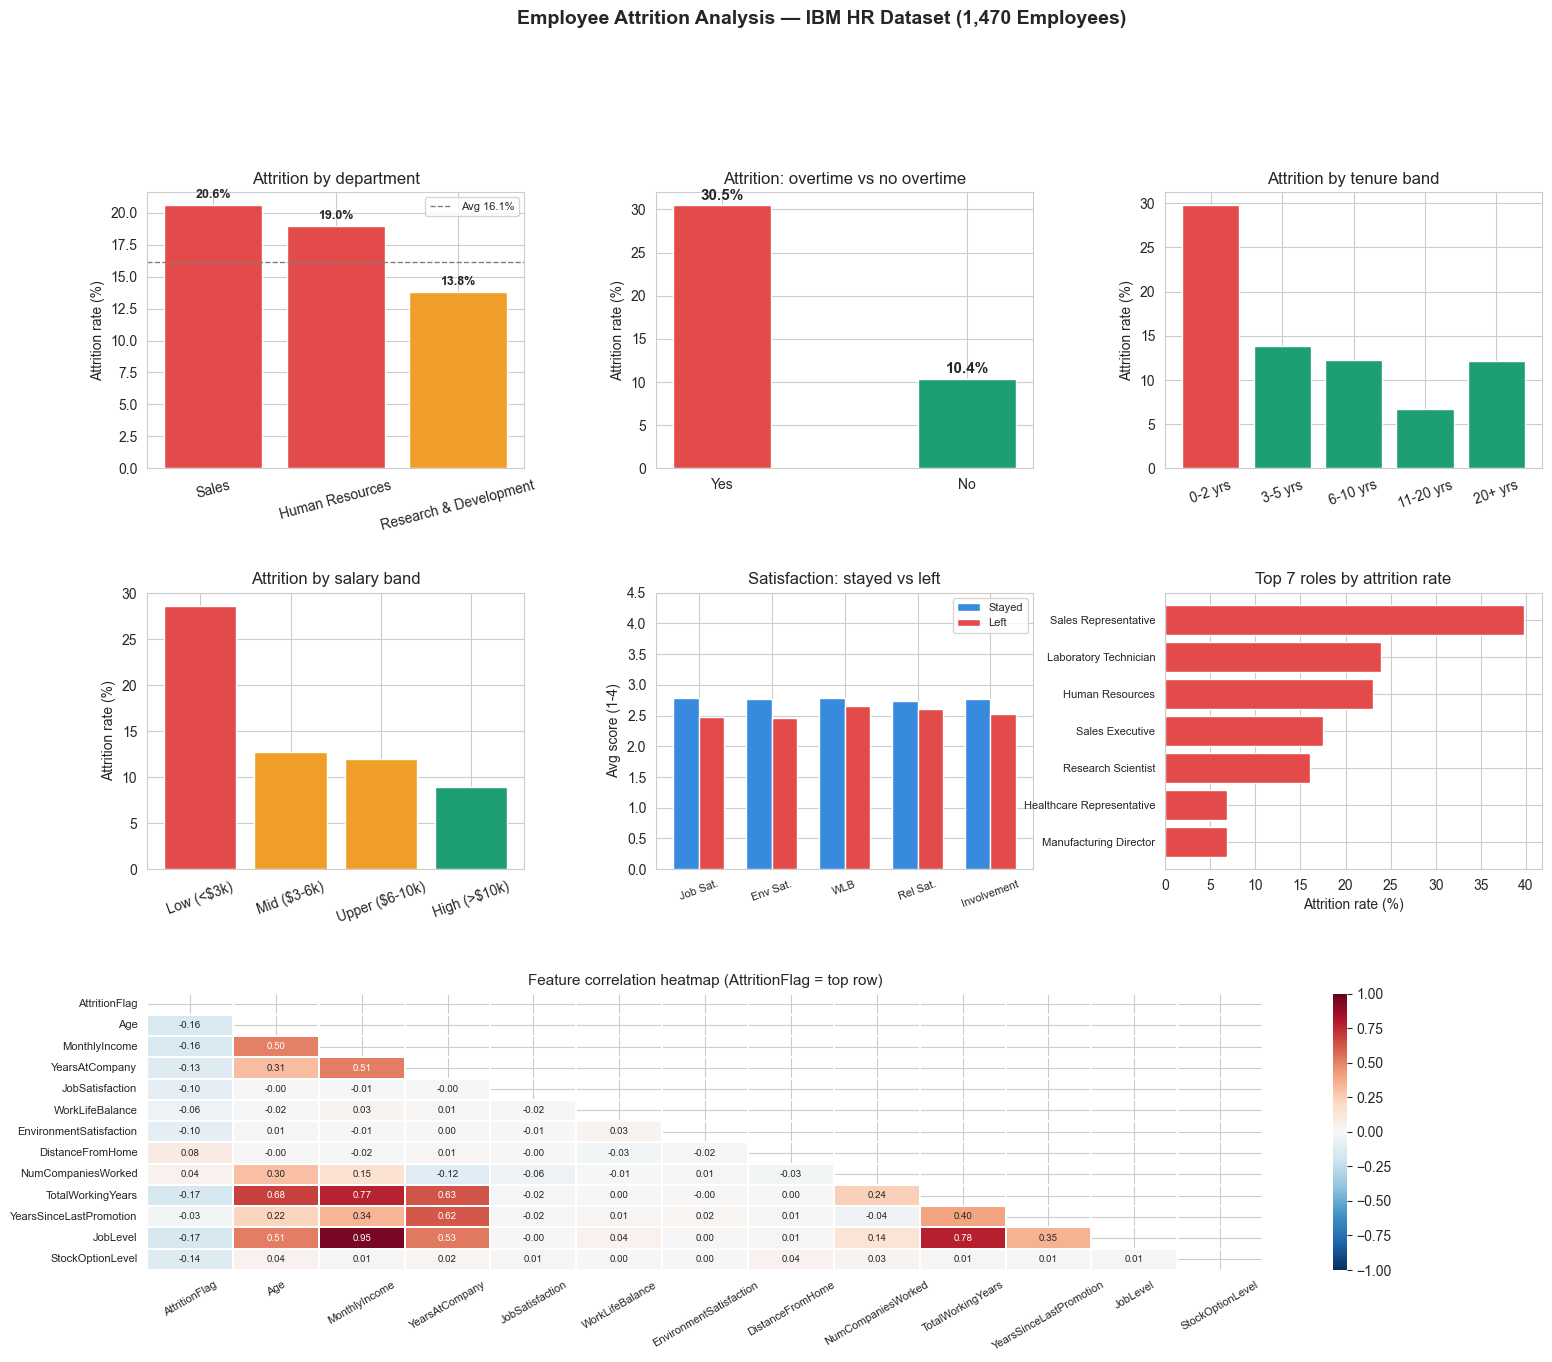

In [7]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Employee Attrition Analysis — IBM HR Dataset (1,470 Employees)',
             fontsize=14, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1 — Attrition by department
ax1 = fig.add_subplot(gs[0, 0])
dept_colors = ['#E24B4A' if v > 15 else '#EF9F27' if v > 10 else '#1D9E75'
               for v in by_dept['attrition_rate']]
bars = ax1.bar(by_dept.index, by_dept['attrition_rate'], color=dept_colors)
ax1.axhline(df['AttritionFlag'].mean()*100, color='gray',
            linestyle='--', linewidth=1, label=f'Avg {df["AttritionFlag"].mean()*100:.1f}%')
ax1.set_ylabel('Attrition rate (%)')
ax1.set_title('Attrition by department')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, by_dept['attrition_rate']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 2 — Attrition by overtime
ax2 = fig.add_subplot(gs[0, 1])
ot_colors = ['#E24B4A', '#1D9E75']
bars2 = ax2.bar(by_overtime.index, by_overtime['attrition_rate'], color=ot_colors, width=0.4)
ax2.set_ylabel('Attrition rate (%)')
ax2.set_title('Attrition: overtime vs no overtime')
for bar, val in zip(bars2, by_overtime['attrition_rate']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Panel 3 — Attrition by tenure band
ax3 = fig.add_subplot(gs[0, 2])
tenure_data = by_tenure.reindex(['0-2 yrs','3-5 yrs','6-10 yrs','11-20 yrs','20+ yrs'])
t_colors = ['#E24B4A' if v > 20 else '#EF9F27' if v > 15 else '#1D9E75'
            for v in tenure_data['attrition_rate']]
ax3.bar(tenure_data.index, tenure_data['attrition_rate'], color=t_colors)
ax3.set_ylabel('Attrition rate (%)')
ax3.set_title('Attrition by tenure band')
ax3.tick_params(axis='x', rotation=20)

# Panel 4 — Attrition by salary band
ax4 = fig.add_subplot(gs[1, 0])
sal_data = by_salary.reindex(['Low (<$3k)','Mid ($3-6k)','Upper ($6-10k)','High (>$10k)'])
s_colors = ['#E24B4A' if v > 20 else '#EF9F27' if v > 10 else '#1D9E75'
            for v in sal_data['attrition_rate']]
ax4.bar(sal_data.index, sal_data['attrition_rate'], color=s_colors)
ax4.set_ylabel('Attrition rate (%)')
ax4.set_title('Attrition by salary band')
ax4.tick_params(axis='x', rotation=20)

# Panel 5 — Satisfaction scores comparison
ax5 = fig.add_subplot(gs[1, 1])
x = np.arange(len(satisfaction_cols))
width = 0.35
stayed_vals = sat_comparison['Stayed'].values
left_vals   = sat_comparison['Left'].values
ax5.bar(x - width/2, stayed_vals, width, label='Stayed', color='#378ADD')
ax5.bar(x + width/2, left_vals,   width, label='Left',   color='#E24B4A')
ax5.set_xticks(x)
ax5.set_xticklabels(['Job Sat.', 'Env Sat.', 'WLB', 'Rel Sat.', 'Involvement'],
                    rotation=20, fontsize=8)
ax5.set_ylabel('Avg score (1-4)')
ax5.set_title('Satisfaction: stayed vs left')
ax5.legend(fontsize=8)
ax5.set_ylim(0, 4.5)

# Panel 6 — Top job roles by attrition
ax6 = fig.add_subplot(gs[1, 2])
top_roles = by_role.head(7)
ax6.barh(top_roles.index, top_roles['attrition_rate'], color='#E24B4A')
ax6.set_xlabel('Attrition rate (%)')
ax6.set_title('Top 7 roles by attrition rate')
ax6.invert_yaxis()
ax6.tick_params(axis='y', labelsize=8)

# Panel 7 — Correlation heatmap (bottom full width)
ax7 = fig.add_subplot(gs[2, :])
numeric_cols = [
    'AttritionFlag', 'Age', 'MonthlyIncome', 'YearsAtCompany',
    'JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction',
    'DistanceFromHome', 'NumCompaniesWorked', 'TotalWorkingYears',
    'YearsSinceLastPromotion', 'JobLevel', 'StockOptionLevel'
]
corr = df[numeric_cols].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax7,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, square=False
)
ax7.set_title('Feature correlation heatmap (AttritionFlag = top row)', fontsize=11)
ax7.tick_params(axis='x', rotation=30, labelsize=8)
ax7.tick_params(axis='y', rotation=0, labelsize=8)

plt.savefig('attrition_dashboard.png', dpi=150, bbox_inches='tight')
print('Dashboard saved as attrition_dashboard.png')
plt.show()

## Step 8 — Export + Business Insight Summary

In [8]:
os.makedirs('output', exist_ok=True)

# Intervention priority list — high risk employees still at company
still_here = df[df['Attrition'] == 'No'].copy()
still_here['RiskScore'] = (
    (still_here['OverTime'] == 'Yes').astype(int) * 3 +
    (still_here['YearsAtCompany'] <= 2).astype(int) * 2 +
    (still_here['JobSatisfaction'] <= 2).astype(int) * 2 +
    (still_here['WorkLifeBalance'] <= 2).astype(int) * 2 +
    (still_here['MonthlyIncome'] < 3000).astype(int) * 1 +
    (still_here['YearsSinceLastPromotion'] >= 4).astype(int) * 1
)

intervention_list = (
    still_here[still_here['RiskScore'] >= 5]
    [['EmployeeNumber', 'Department', 'JobRole', 'MonthlyIncome',
      'YearsAtCompany', 'JobSatisfaction', 'WorkLifeBalance',
      'OverTime', 'RiskScore']]
    .sort_values('RiskScore', ascending=False)
)

intervention_list.to_csv('output/intervention_priority_list.csv', index=False)
by_dept.to_csv('output/attrition_by_department.csv')
by_role.to_csv('output/attrition_by_role.csv')
cost_by_dept.to_csv('output/turnover_cost_by_dept.csv')
sat_comparison.to_csv('output/satisfaction_comparison.csv')

overall_rate = df['AttritionFlag'].mean() * 100
worst_dept   = by_dept.index[0]
worst_role   = by_role.index[0]
ot_yes_rate  = by_overtime.loc['Yes', 'attrition_rate'] if 'Yes' in by_overtime.index else 'N/A'
ot_no_rate   = by_overtime.loc['No', 'attrition_rate'] if 'No' in by_overtime.index else 'N/A'

print('=' * 60)
print('BUSINESS INSIGHT SUMMARY')
print('=' * 60)
print(f'Total employees analysed:    {len(df):,}')
print(f'Overall attrition rate:      {overall_rate:.1f}%')
print(f'Employees who left:          {df["AttritionFlag"].sum()}')
print(f'Total estimated cost:        ${total_cost:,.0f}')
print()
print(f'Highest risk department:     {worst_dept} ({by_dept.iloc[0]["attrition_rate"]}% rate)')
print(f'Highest risk job role:       {worst_role} ({by_role.iloc[0]["attrition_rate"]}% rate)')
print(f'Overtime attrition rate:     {ot_yes_rate}% (vs {ot_no_rate}% without overtime)')
print(f'Highest attrition tenure:    {by_tenure.index[0]} band')
print(f'Lowest salary band rate:     {by_salary.iloc[0]["attrition_rate"]}% attrition')
print()
print(f'Employees flagged for intervention: {len(intervention_list)}')
print()
print('TOP 3 RETENTION RECOMMENDATIONS:')
print(f'  1. Address overtime burden — {ot_yes_rate}% vs {ot_no_rate}% attrition rate')
print(f'  2. Focus on {worst_dept} dept — highest attrition rate')
print(f'  3. Review compensation for Low salary band — highest flight risk')
print(f'  4. {len(intervention_list)} employees flagged as high risk — prioritise 1:1 check-ins')
print('=' * 60)

BUSINESS INSIGHT SUMMARY
Total employees analysed:    1,470
Overall attrition rate:      16.1%
Employees who left:          237
Total estimated cost:        $20,421,738

Highest risk department:     Sales (20.6% rate)
Highest risk job role:       Sales Representative (39.8% rate)
Overtime attrition rate:     30.5% (vs 10.4% without overtime)
Highest attrition tenure:    0-2 yrs band
Lowest salary band rate:     28.6% attrition

Employees flagged for intervention: 278

TOP 3 RETENTION RECOMMENDATIONS:
  1. Address overtime burden — 30.5% vs 10.4% attrition rate
  2. Focus on Sales dept — highest attrition rate
  3. Review compensation for Low salary band — highest flight risk
  4. 278 employees flagged as high risk — prioritise 1:1 check-ins


## Summary

### What we built
A full HR attrition analysis pipeline — from raw employee data to a risk-scored intervention priority list with financial cost estimates per department.

### Skills practised
- `pandas` — groupby, agg, pd.cut for banding, apply, feature encoding
- `seaborn` — heatmap with mask, grouped bar charts
- `matplotlib` — GridSpec for complex 6-panel layout
- `numpy` — correlation matrix, masking upper triangle
- Scoring model — rule-based risk scoring on current employees
- Business metrics — turnover cost estimation (1.5x salary rule)

### Business context
The average cost to replace an employee is 1.5x their annual salary. For a company of 1,470 people with a 16% attrition rate, that is a significant annual cost — most of it preventable. The intervention priority list this notebook produces is what an HR business partner would bring into a quarterly talent review meeting.

### Key findings

- Overall attrition rate: 16.1%
- Total estimated turnover cost: $20,421,738
- Highest risk department: Sales (20.6% rate)
- Highest risk role: Sales Representative (39.8% rate)
- Overtime attrition rate vs no overtime: 30.5% (vs 10.4% without overtime)
- Employees flagged for intervention: 278